# E-Commerce Sales & Profitability Analysis

## Introduction

I wanted to understand how this e-commerce business is performing and, more importantly, where the money is coming from and where it is being lost.

This analysis looks at sales, profitability, products, regions, countries, customer segments, discounts, and payment methods. The goal is to find a few useful patterns that could help a business make better decisions.

### Questions I wanted to answer

- How have sales changed over time?
- Which products and categories generate the most sales?
- How common are loss-making orders?
- Which products are responsible for the losses?
- Which regions and countries perform best?
- Which customer segment is most valuable?
- Are discounts associated with lower profitability?
- How do payment methods compare?

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load the data

In [2]:
df = pd.read_csv("../data/global_ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,"1,058.14",11.09,253.44,Credit Card


## 3. Initial data check

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 2,000
Columns: 15


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   str    
 1   Order_Date        2000 non-null   str    
 2   Customer_Name     2000 non-null   str    
 3   Customer_Segment  2000 non-null   str    
 4   Country           2000 non-null   str    
 5   Region            2000 non-null   str    
 6   Product_Category  2000 non-null   str    
 7   Product_Name      2000 non-null   str    
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   str    
dtypes: float64(4), int64(2), str(9)
memory usage: 234.5 KB


In [5]:
df.describe()

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,"2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00"
mean,3.56,73.33,8.57,242.28,12.90,79.44
std,2.70,79.31,7.26,382.58,5.22,137.57
min,1.00,3.03,0.00,2.42,5.52,-11.28
25%,2.00,18.76,0.00,41.23,9.46,6.87
50%,3.00,46.42,10.00,113.12,11.84,32.83
75%,5.00,90.25,15.00,266.55,14.92,90.30
max,15.00,472.56,30.00,"3,813.98",40.44,"1,373.63"


In [6]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

In [7]:
duplicate_orders = df["Order_ID"].duplicated().sum()
print("Duplicate Order_IDs:", duplicate_orders)

Duplicate Order_IDs: 0


### Initial observations

The dataset contains 2,000 orders and 15 columns. I also checked for missing values and duplicate order IDs before starting the analysis.

Since each `Order_ID` represents an order and the IDs are unique, I can use the order ID count as an order count in later summaries.

## 4. Data preparation

In [8]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Day_Name"] = df["Order_Date"].dt.day_name()

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method,Year,Month,Month_Name,Day_Name
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery,2023,1,January,Monday
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery,2023,1,January,Monday
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card,2023,1,January,Tuesday
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal,2023,1,January,Tuesday
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,"1,058.14",11.09,253.44,Credit Card,2023,1,January,Thursday


In [9]:
# Check that Total_Sales agrees with the basic sales calculation:
# quantity × unit price × (1 - discount)

df["calculated_sales"] = (
    df["Quantity"]
    * df["Unit_Price"]
    * (1 - df["Discount_Percent"] / 100)
)

sales_difference = (
    df["Total_Sales"] - df["calculated_sales"]
).abs()

print("Largest sales calculation difference:", sales_difference.max())

Largest sales calculation difference: 0.005000000000002558


In [10]:
# The calculated column was only used as a validation check.
df.drop(columns="calculated_sales", inplace=True)

## 5. Sales analysis

I started with the simplest question: how much is the business selling, and how does that change over time?

In [11]:
total_sales = df["Total_Sales"].sum()
total_orders = df["Order_ID"].nunique()

print(f"Total sales: ${total_sales:,.2f}")
print(f"Total orders: {total_orders:,}")
print(f"Average order value: ${total_sales / total_orders:,.2f}")

Total sales: $484,559.34
Total orders: 2,000
Average order value: $242.28


### Sales by year

In [12]:
yearly_sales = (
    df.groupby("Year")["Total_Sales"]
    .sum()
    .sort_index()
)

yearly_sales

Year
2023   164,443.45
2024   155,150.73
2025   164,965.16
Name: Total_Sales, dtype: float64

In [13]:
yearly_growth = yearly_sales.pct_change() * 100
yearly_growth

Year
2023     NaN
2024   -5.65
2025    6.33
Name: Total_Sales, dtype: float64

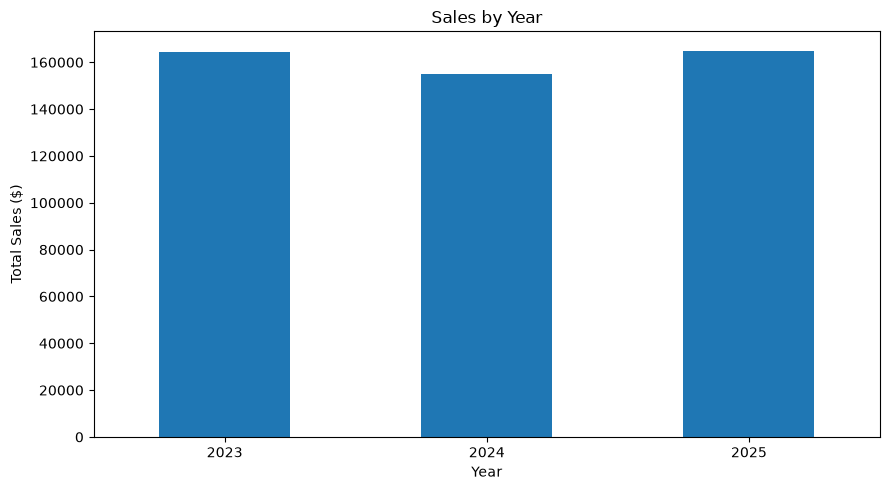

In [14]:
yearly_sales.plot(kind="bar", figsize=(9, 5))
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The yearly results show that sales were relatively stable across the three years. There was a decline from 2023 to 2024, followed by a recovery in 2025.

Based on the data, sales were:
- 2023: $164,443.45
- 2024: $155,150.73
- 2025: $164,965.16

So 2025 recovered from the previous year's decline and slightly exceeded 2023 sales.

### Monthly sales

In [15]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"]
    .sum()
)

monthly_sales

Order_Date
2023-01   11,275.20
2023-02   16,943.67
2023-03   16,056.45
2023-04   12,185.00
2023-05    8,218.47
2023-06   16,191.61
2023-07   15,667.73
2023-08   12,971.07
2023-09   11,989.72
2023-10   17,794.60
2023-11    8,475.49
2023-12   16,674.44
2024-01    8,015.21
2024-02   11,979.60
2024-03   10,550.11
2024-04   15,615.06
2024-05   16,594.20
2024-06    9,435.15
2024-07   14,937.53
2024-08    9,883.83
2024-09    9,636.38
2024-10   17,426.05
2024-11   16,413.27
2024-12   14,664.34
2025-01   12,321.18
2025-02    7,337.28
2025-03    7,772.33
2025-04   16,403.60
2025-05   17,621.80
2025-06   18,068.09
2025-07   15,065.96
2025-08   11,302.11
2025-09   14,375.95
2025-10   15,874.75
2025-11   14,781.02
2025-12   14,041.09
Freq: M, Name: Total_Sales, dtype: float64

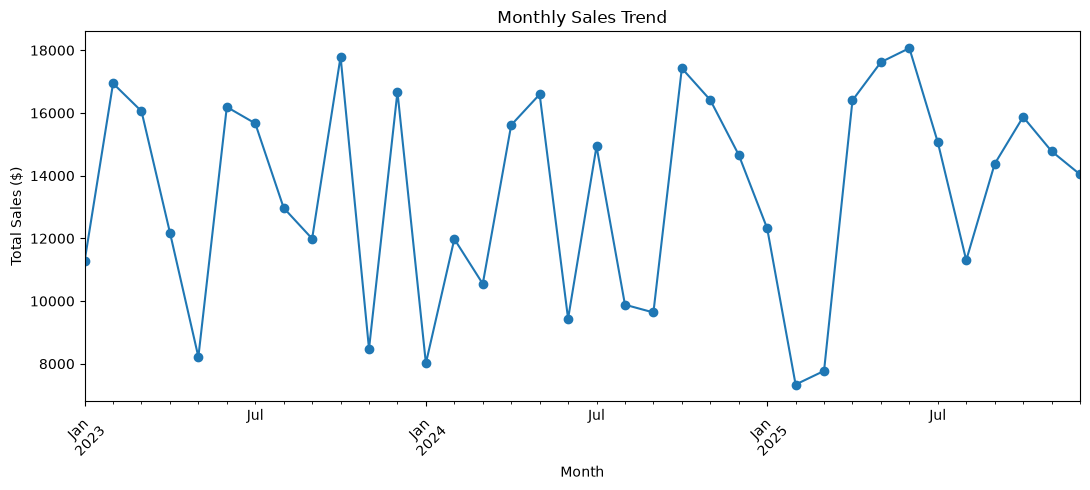

In [16]:
monthly_sales.plot(kind="line", marker="o", figsize=(11, 5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()

print("Best month:", best_month, f"(${monthly_sales.max():,.2f})")
print("Lowest month:", worst_month, f"(${monthly_sales.min():,.2f})")

Best month: 2025-06 ($18,068.09)
Lowest month: 2025-02 ($7,337.28)


### A closer look at February and June 2025

February and June stood out as useful months to compare. June had more orders and more units sold, and its average order value was also much higher.

- February: 40 orders, 114 units, AOV ≈ $183.43
- June: 64 orders, 209 units, AOV ≈ $282.31

The category mix also changed noticeably between the two months, with Technology leading February sales and Furniture becoming much stronger in June.

### Sales by product category

In [18]:
category_sales = (
    df.groupby("Product_Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Product_Category
Furniture                256,274.68
Technology               139,518.22
Clothing & Accessories    69,375.63
Office Supplies           19,390.81
Name: Total_Sales, dtype: float64

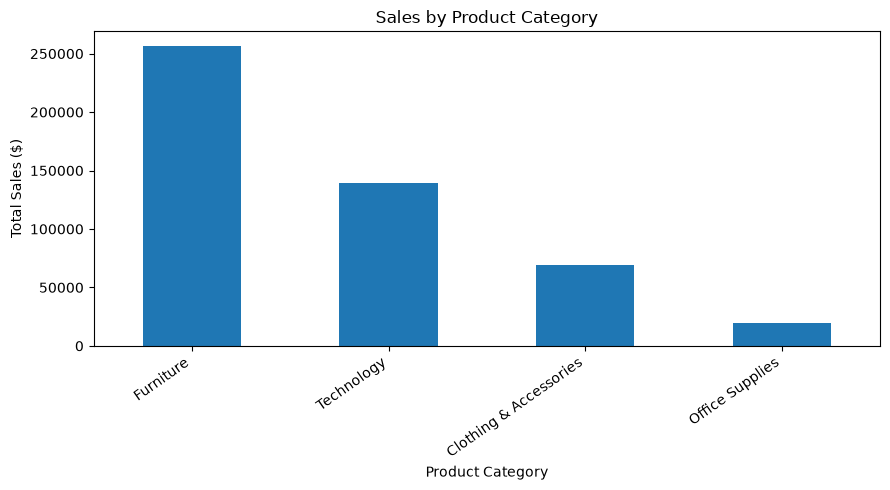

In [19]:
category_sales.plot(kind="bar", figsize=(9, 5))
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Top 10 products by sales

In [20]:
top_products_sales = (
    df.groupby("Product_Name")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_sales

Product_Name
Standing Desk Converter         46,614.22
Ergonomic Office Chair          45,405.15
Corner L-Shaped Desk            41,070.48
Mesh Back Task Chair            38,179.77
Wireless Bluetooth Headphones   28,258.70
Mechanical Gaming Keyboard      24,072.42
Filing Cabinet 3-Drawer         23,108.01
Folding Table Portable          18,663.13
Portable External SSD 1TB       18,065.30
Bookshelf 5-Tier                17,741.59
Name: Total_Sales, dtype: float64

The strongest individual products by sales were led by Standing Desk Converter, Ergonomic Office Chair, Corner L-Shaped Desk, and Mesh Back Task Chair.

The top four were all Furniture products, which is consistent with the strong Furniture performance seen in the June comparison.

## 6. Profitability analysis

In [21]:
total_profit = df["Profit"].sum()
average_profit = df["Profit"].mean()
profit_margin = total_profit / total_sales * 100

profitable_orders = (df["Profit"] > 0).sum()
loss_orders_count = (df["Profit"] < 0).sum()
zero_profit_orders = (df["Profit"] == 0).sum()

print(f"Total profit: ${total_profit:,.2f}")
print(f"Average profit per order: ${average_profit:,.2f}")
print(f"Overall profit margin: {profit_margin:.2f}%")
print()
print("Profitable orders:", profitable_orders)
print("Loss-making orders:", loss_orders_count)
print("Zero-profit orders:", zero_profit_orders)

Total profit: $158,872.32
Average profit per order: $79.44
Overall profit margin: 32.79%

Profitable orders: 1728
Loss-making orders: 272
Zero-profit orders: 0


There are 1,728 profitable orders and 272 loss-making orders. That means **13.6% of all orders are loss-making**.

The business still has a healthy overall positive profit, but the loss-making orders are worth investigating because they are concentrated in particular products and categories.

### Losses by product category

In [22]:
loss_orders = df[df["Profit"] < 0].copy()

loss_by_category = (
    loss_orders
    .groupby("Product_Category")["Profit"]
    .agg(["count", "sum", "mean"])
    .sort_values("count", ascending=False)
)

loss_by_category

,count,sum,mean
Product_Category,,,
Office Supplies,224,-827.99,-3.70
Clothing & Accessories,23,-56.00,-2.43
Technology,15,-37.04,-2.47
Furniture,10,-32.36,-3.24


Office Supplies stands out immediately. It accounts for 224 of the 272 loss-making orders, or about **82.4%** of all loss-making orders.

That makes Office Supplies the first category I would investigate rather than assuming the losses are spread evenly across the business.

### Office Supplies: which products are driving the losses?

In [23]:
office_supply_losses = (
    loss_orders[loss_orders["Product_Category"] == "Office Supplies"]
    .groupby("Product_Name")["Profit"]
    .agg(["count", "sum", "mean"])
    .sort_values("count", ascending=False)
)

office_supply_losses

,count,sum,mean
Product_Name,,,
Paper Clips Box 500pc,36,-171.73,-4.77
Sticky Notes Multicolor 6-Pack,27,-94.57,-3.50
Binder Clips Assorted 48pc,26,-95.27,-3.66
Desk Calendar 2025,25,-79.31,-3.17
Highlighters Neon Pack 6,23,-97.52,-4.24
Stapler Full-Size,22,-61.28,-2.79
Ballpoint Pen Pack 12,21,-75.41,-3.59
Whiteboard Markers Set 8,21,-82.34,-3.92
Premium Notebook Set A5,12,-42.55,-3.55


### Are those products actually unprofitable overall?

In [24]:
office_supply_profitability = (
    df[df["Product_Category"] == "Office Supplies"]
    .groupby("Product_Name")["Profit"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum")
)

office_supply_profitability

,count,sum,mean
Product_Name,,,
Paper Clips Box 500pc,45,-79.95,-1.78
Highlighters Neon Pack 6,39,-0.37,-0.01
Sticky Notes Multicolor 6-Pack,39,61.90,1.59
Binder Clips Assorted 48pc,58,214.49,3.70
Ballpoint Pen Pack 12,50,254.45,5.09
Whiteboard Markers Set 8,59,311.95,5.29
Desk Calendar 2025,59,489.92,8.30
Stapler Full-Size,58,544.94,9.40
Premium Notebook Set A5,53,665.31,12.55


This distinction is important.

A product can have many loss-making orders and still make a positive profit overall. Looking at all orders shows that **Paper Clips Box 500pc is genuinely unprofitable overall**, with total profit of -$79.95 across 45 orders.

Highlighters Neon Pack 6 is essentially break-even, with a slightly negative total profit of -$0.37.

### Loss order rate

In [25]:
total_office_orders = (
    df[df["Product_Category"] == "Office Supplies"]
    .groupby("Product_Name")
    .size()
)

loss_office_orders = (
    loss_orders[loss_orders["Product_Category"] == "Office Supplies"]
    .groupby("Product_Name")
    .size()
)

loss_rate = (
    loss_office_orders
    .div(total_office_orders)
    .fillna(0)
    .mul(100)
    .sort_values(ascending=False)
)

loss_rate

Product_Name
Paper Clips Box 500pc            80.00
Sticky Notes Multicolor 6-Pack   69.23
Highlighters Neon Pack 6         58.97
Binder Clips Assorted 48pc       44.83
Desk Calendar 2025               42.37
Ballpoint Pen Pack 12            42.00
Stapler Full-Size                37.93
Whiteboard Markers Set 8         35.59
Premium Notebook Set A5          22.64
Tape Dispenser Heavy Duty        20.75
dtype: float64

Paper Clips Box 500pc has the highest loss order rate at **80%**. In other words, 36 of its 45 orders were loss-making.

Sticky Notes Multicolor 6-Pack and Highlighters Neon Pack 6 also have high loss rates.

This suggests that some low-value Office Supplies products may need a closer look at pricing, discounting, or shipping economics.

### Profitable vs loss-making orders

In [26]:
profitability_comparison = (
    df.assign(
        Order_Status=np.select(
            [df["Profit"] < 0, df["Profit"] > 0],
            ["Loss", "Profit"],
            default="Zero Profit"
        )
    )
    .groupby("Order_Status")
    .agg(
        Orders=("Order_ID", "count"),
        Avg_Quantity=("Quantity", "mean"),
        Avg_Unit_Price=("Unit_Price", "mean"),
        Avg_Discount=("Discount_Percent", "mean"),
        Avg_Sales=("Total_Sales", "mean"),
        Avg_Shipping_Cost=("Shipping_Cost", "mean"),
        Avg_Profit=("Profit", "mean")
    )
)

profitability_comparison

,Orders,Avg_Quantity,Avg_Unit_Price,Avg_Discount,Avg_Sales,Avg_Shipping_Cost,Avg_Profit
Order_Status,,,,,,,
Loss,272,1.88,12.26,10.17,16.94,11.35,-3.51
Profit,1728,3.82,82.94,8.32,277.75,13.15,92.49


The difference between profitable and loss-making orders is quite large.

Loss-making orders have much lower average unit prices and much lower average sales. Their average sales are only about $16.94 compared with $277.75 for profitable orders.

Interestingly, average shipping cost is not dramatically higher for loss-making orders. This suggests that the issue is less about unusually expensive shipping and more about shipping being a large cost relative to the value of small orders.

### Top 10 products by profit

In [27]:
top_products_profit = (
    df.groupby("Product_Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_profit

Product_Name
Ergonomic Office Chair          15,104.58
Standing Desk Converter         14,694.35
Corner L-Shaped Desk            13,663.00
Mesh Back Task Chair            12,820.11
Wireless Bluetooth Headphones   10,611.08
Mechanical Gaming Keyboard       8,381.19
Filing Cabinet 3-Drawer          7,041.80
Portable External SSD 1TB        6,556.75
Business Casual Blazer           6,004.33
Noise Cancelling Earbuds         5,973.01
Name: Profit, dtype: float64

Ergonomic Office Chair generated the highest total profit at **$15,104.58**, followed by Standing Desk Converter at **$14,694.35**.

This also shows why looking at both sales and profit matters: the product with the highest sales is not necessarily the product with the highest profit.

## 7. Geographic analysis

In [28]:
region_analysis = (
    df.groupby("Region")
    .agg(
        Orders=("Order_ID", "count"),
        Sales=("Total_Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

region_analysis["Profit_Margin"] = (
    region_analysis["Profit"] / region_analysis["Sales"] * 100
)

region_analysis["AOV"] = (
    region_analysis["Sales"] / region_analysis["Orders"]
)

region_analysis.sort_values("Sales", ascending=False)

,Orders,Sales,Profit,Profit_Margin,AOV
Region,,,,,
Europe,503,"137,006.20","45,672.16",33.34,272.38
North America,578,"133,876.38","45,250.09",33.80,231.62
Asia Pacific,520,"121,707.51","39,116.61",32.14,234.05
South America,191,"46,051.13","14,680.98",31.88,241.11
Middle East & Africa,208,"45,918.12","14,152.48",30.82,220.76


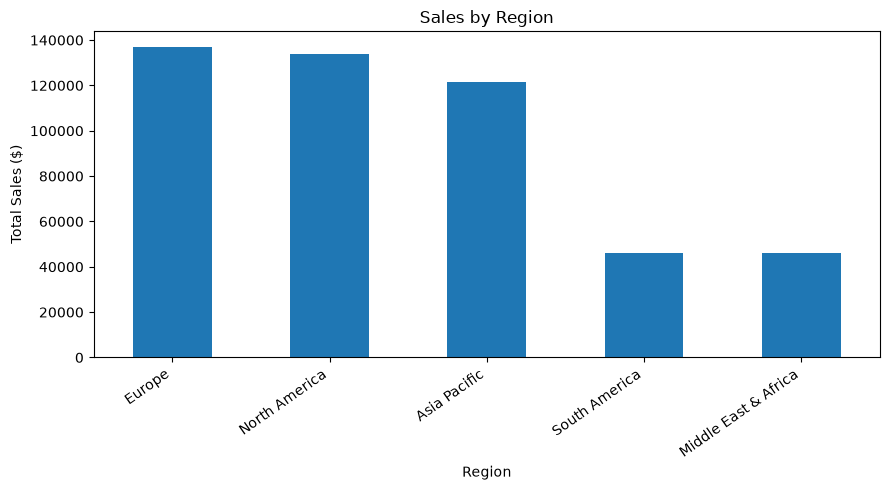

In [29]:
region_analysis["Sales"].sort_values(ascending=False).plot(
    kind="bar", figsize=(9, 5)
)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

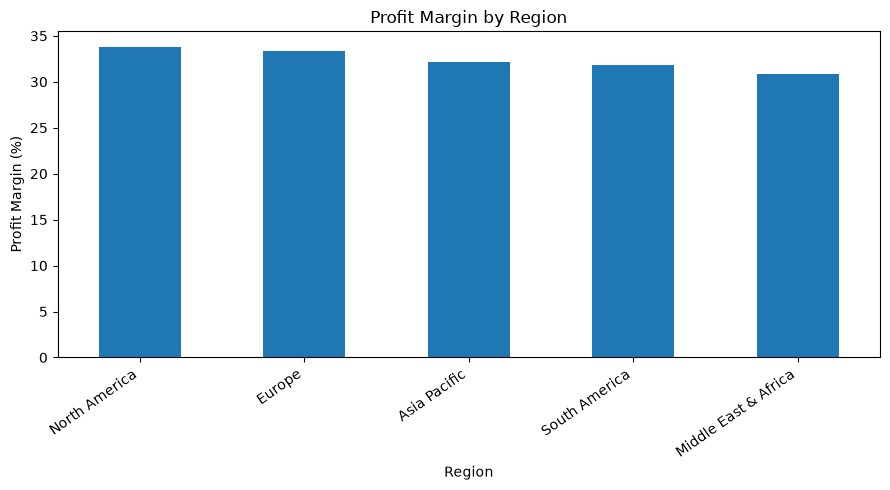

In [30]:
region_analysis["Profit_Margin"].sort_values(ascending=False).plot(
    kind="bar", figsize=(9, 5)
)
plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Europe generated the highest total sales at **$137,006.20**, while North America had the highest number of orders at 578 and the highest profit margin at about **33.80%**.

Europe's AOV was about **$272.38**, compared with about **$231.62** in North America. This helps explain why Europe generated slightly more sales despite having fewer orders.

### Country-level performance

In [31]:
country_analysis = (
    df.groupby("Country")
    .agg(
        Orders=("Order_ID", "count"),
        Sales=("Total_Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

country_analysis["Profit_Margin"] = (
    country_analysis["Profit"] / country_analysis["Sales"] * 100
)

country_analysis["AOV"] = (
    country_analysis["Sales"] / country_analysis["Orders"]
)

country_analysis.sort_values("Sales", ascending=False)

,Orders,Sales,Profit,Profit_Margin,AOV
Country,,,,,
Mexico,203,"47,217.30","15,949.44",33.78,232.60
Canada,179,"45,326.55","15,320.95",33.80,253.22
United States,196,"41,332.53","13,979.70",33.82,210.88
Japan,124,"30,950.19","9,826.31",31.75,249.60
United Kingdom,106,"30,185.46","10,185.32",33.74,284.77
Germany,95,"28,989.73","9,518.07",32.83,305.16
China,109,"28,322.85","9,028.07",31.88,259.84
Italy,105,"27,484.38","9,125.06",33.20,261.76
France,105,"26,616.81","8,973.46",33.71,253.49


In [32]:
country_analysis.sort_values("Profit", ascending=False).head(5)

,Orders,Sales,Profit,Profit_Margin,AOV
Country,,,,,
Mexico,203,"47,217.30","15,949.44",33.78,232.60
Canada,179,"45,326.55","15,320.95",33.80,253.22
United States,196,"41,332.53","13,979.70",33.82,210.88
United Kingdom,106,"30,185.46","10,185.32",33.74,284.77
Japan,124,"30,950.19","9,826.31",31.75,249.60


Mexico was the largest country by both sales and total profit, followed by Canada and the United States.

The same countries that lead sales also lead total profit, so there is no major mismatch between revenue leadership and profit leadership at the country level.

## 8. Customer segment analysis

In [33]:
segment_analysis = (
    df.groupby("Customer_Segment")
    .agg(
        Orders=("Order_ID", "count"),
        Sales=("Total_Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

segment_analysis["AOV"] = (
    segment_analysis["Sales"] / segment_analysis["Orders"]
)

segment_analysis["Profit_Margin"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"] * 100
)

segment_analysis.sort_values("Sales", ascending=False)

,Orders,Sales,Profit,AOV,Profit_Margin
Customer_Segment,,,,,
Consumer,1006,"256,287.74","87,300.36",254.76,34.06
Corporate,623,"146,050.39","44,463.44",234.43,30.44
Home Office,371,"82,221.21","27,108.52",221.62,32.97


Consumer customers are the strongest segment in this dataset.

They generated:
- **1,006 orders**
- **$256,287.74 sales**
- **$87,300.36 profit**
- **$254.76 AOV**
- **34.06% profit margin**

Corporate customers are still an important source of revenue, but their profit margin is lower at about **30.44%**.

### Discounts by customer segment

In [34]:
segment_discount = (
    df.groupby("Customer_Segment")["Discount_Percent"]
    .agg(["mean", "median"])
    .sort_values("mean", ascending=False)
)

segment_discount

,mean,median
Customer_Segment,,
Corporate,11.25,10.00
Home Office,7.80,5.00
Consumer,7.20,5.00


Corporate customers receive noticeably higher discounts.

Their average discount is about **11.25%**, compared with **7.20%** for Consumer customers. The median shows the same pattern: 10% for Corporate versus 5% for Consumer.

This is a possible contributor to the lower Corporate profit margin, although the analysis does not by itself prove that discounting is the cause.

### Discount and profit relationship

In [35]:
discount_profit_corr = df["Discount_Percent"].corr(df["Profit"])
print(f"Discount-Profit correlation: {discount_profit_corr:.3f}")

Discount-Profit correlation: -0.141


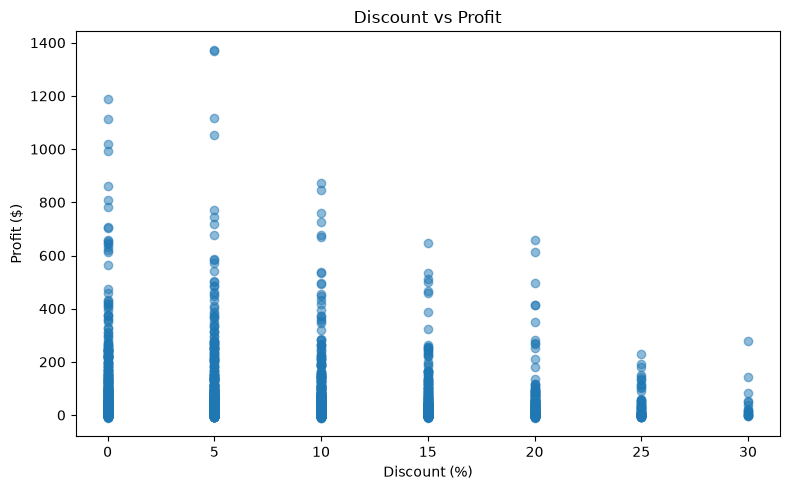

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount_Percent"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

Correlation is useful here as a quick way to check whether discount and profit move together, but it should not be interpreted as proof that discounts cause changes in profit. Other factors such as product price, quantity, and shipping cost also affect profitability.

## 9. Payment method analysis

In [37]:
payment_analysis = (
    df.groupby("Payment_Method")
    .agg(
        Orders=("Order_ID", "count"),
        Sales=("Total_Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

payment_analysis["AOV"] = (
    payment_analysis["Sales"] / payment_analysis["Orders"]
)

payment_analysis["Profit_Margin"] = (
    payment_analysis["Profit"] / payment_analysis["Sales"] * 100
)

payment_analysis.sort_values("Sales", ascending=False)

,Orders,Sales,Profit,AOV,Profit_Margin
Payment_Method,,,,,
Credit Card,797,"192,717.89","62,323.24",241.80,32.34
PayPal,609,"143,112.87","47,288.80",235.00,33.04
Cash on Delivery,301,"77,129.54","25,704.89",256.24,33.33
Bank Transfer,293,"71,599.04","23,555.39",244.37,32.90


Credit Card is the dominant payment method, with **797 orders** and **$192,717.89 in sales**.

Cash on Delivery has the highest AOV at about **$256.24** and the highest profit margin at about **33.33%**, although the differences in margin between payment methods are relatively small.

## 10. Key findings

### What I found

**1. Sales recovered in 2025.**  
Sales fell from $164,443.45 in 2023 to $155,150.73 in 2024, then recovered to $164,965.16 in 2025.

**2. Losses are concentrated in Office Supplies.**  
There were 272 loss-making orders, and 224 of them were Office Supplies orders. That is about 82.4% of all loss-making orders.

**3. Paper Clips Box 500pc is the clearest product problem.**  
It had 45 total orders, 36 of which were loss-making, giving it an 80% loss order rate and a total profit of -$79.95.

**4. Loss-making orders are generally low-value orders.**  
Average sales were about $16.94 for loss-making orders versus $277.75 for profitable orders. Shipping cost is not substantially higher on loss-making orders, so shipping appears to be a large cost relative to small order values.

**5. Europe leads total sales.**  
Europe generated $137,006.20 in sales, helped by an AOV of about $272.38.

**6. North America has the highest regional margin.**  
North America had a 33.80% profit margin, although the regional margins are fairly close overall.

**7. Consumers are the strongest customer segment.**  
Consumers generated the highest sales, profit, AOV, and profit margin.

**8. Corporate customers receive higher discounts.**  
Corporate customers averaged an 11.25% discount compared with 7.20% for Consumers, while also having the lowest segment profit margin.

## 11. Business recommendations

### 1. Review pricing for low-value Office Supplies

Paper Clips Box 500pc is the clearest example of a product that should be reviewed. The business could test a higher price, lower discount, or minimum order quantity.

### 2. Consider bundling small Office Supplies

Products with low order values can struggle to absorb shipping costs. Bundling related products could increase order value without necessarily requiring a large increase in acquisition or delivery costs.

### 3. Review Corporate discounting

Corporate customers generate substantial revenue, but their margin is lower than the other segments. Discount rules could be reviewed to see whether larger discounts are being given where they are not necessary.

### 4. Protect high-performing Furniture products

Several Furniture products appear among the strongest products by both sales and profit. These products could be given more attention in inventory planning and marketing.

### 5. Focus on high-value markets while watching efficiency

Europe is the strongest sales region, while North America has the highest margin. Both are useful markets, but the strategy should consider both revenue volume and profitability rather than focusing on sales alone.

## 12. Conclusion

Overall, the business is profitable, with total profit of **$158,872.32** and an overall profit margin of about **32.79%**.

The main opportunity is not simply to increase sales. A more useful priority is to reduce avoidable losses, especially in low-value Office Supplies orders, while continuing to support strong products and customer segments.

The biggest lesson from this analysis is that revenue alone does not tell the whole story. Looking at sales together with profit, order value, discounts, and loss rates gives a much clearer picture of how the business is performing.

## 13. Reproducibility

In [38]:
# Dataset dimensions used in the analysis
print("Dataset shape:", df.shape)

# Final columns
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (2000, 19)

Columns:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Name', 'Day_Name']
